# EDA: macro_scenarios.csv

This notebook explores the raw `macro_scenarios.csv` file. It holds 500 macroeconomic
shock scenarios, ranging from mild to severe, each with a GDP shock, an unemployment
shock, a rate shock, a credit spread widening, an inflation shock, and a currency
devaluation figure. These are the scenarios every bank is tested against.

This notebook only explores and records data-quality issues. Cleaning happens in
`notebooks/data_cleaning.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Load and inspect

In [2]:
raw = pd.read_csv('../raw/macro_scenarios.csv', dtype=str, keep_default_na=False)
print('shape:', raw.shape)
raw.head()

shape: (504, 9)


,scenario_id,stress_intensity,scenario_severity,gdp_shock_pp,unemp_shock_pp,rate_shock_pp,credit_spread_bps,inflation_shock_pp,fx_devaluation_pct
0,SCN_0001,0.677,adverse,-7.74,6.76,-0.23,332.0,11.06,26.75
1,SCN_0002,0.89,severe,-9.76,9.41,5.06,460.1,18.19,40.96
2,SCN_0003,0.195,mild,-2.9,2.7,-0.53,71.3,1.72,8.94
3,SCN_0004,0.135,mild,-2.01,1.01,0.35,49.8,7.72,6.2
4,SCN_0005,0.61,adverse,-7.62,6.01,3.95,252.2,5.71,12.31


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   scenario_id         504 non-null    str  
 1   stress_intensity    504 non-null    str  
 2   scenario_severity   504 non-null    str  
 3   gdp_shock_pp        504 non-null    str  
 4   unemp_shock_pp      504 non-null    str  
 5   rate_shock_pp       504 non-null    str  
 6   credit_spread_bps   504 non-null    str  
 7   inflation_shock_pp  504 non-null    str  
 8   fx_devaluation_pct  504 non-null    str  
dtypes: str(9)
memory usage: 35.6 KB


## 2. Duplicate scenarios

In [4]:
print('Fully duplicated rows:', raw.duplicated().sum())
print('Duplicated scenario_id values:', raw['scenario_id'].duplicated().sum())

Fully duplicated rows: 4
Duplicated scenario_id values: 4


**Conclusion.** There are 4 exact duplicate rows. Testing a bank against the same
scenario twice would not change any individual result, but it would double-weight that
scenario in any aggregate statistic, such as the average CAR drop across all 500
scenarios.

## 3. scenario_severity: category fragmentation

In [5]:
print('Unique scenario_severity values, sorted:')
for v in sorted(raw['scenario_severity'].unique(), key=str.lower):
    print(repr(v))

Unique scenario_severity values, sorted:
''
' mild'
' severe'
'advers'
'adverse'
'ADVERSE'
'Adverse'
'baseline'
'baseline '
'mild'
'MILD'
'Mild'
'mld'
'moderat'
'moderate'
'MODERATE'
'Moderate'
'sever'
'severe'
'SEVERE'
'Severe'
'TBD'
'unknown'


**Conclusion.** There should be five severity levels: `baseline`, `mild`,
`moderate`, `adverse`, `severe`. Instead there are 15 variants once mixed casing
(`Adverse` vs `ADVERSE`), typos (`sever`, `advers`, `mld`, `moderat`), stray
whitespace, and a few blank or placeholder entries (`unknown`, `TBD`) are all counted
separately.

## 4. Numeric fields stored as text

In [6]:
def non_numeric_values(series):
    out = []
    for v in series.unique():
        cleaned = v.lower().replace('bps', '').strip()
        if cleaned in ('', 'n/a', 'na', '-', '--'):
            out.append(v)
            continue
        try:
            float(cleaned)
        except ValueError:
            out.append(v)
    return out

for col in ['gdp_shock_pp', 'unemp_shock_pp', 'rate_shock_pp', 'credit_spread_bps',
            'inflation_shock_pp', 'fx_devaluation_pct', 'stress_intensity']:
    bad = non_numeric_values(raw[col])
    print(f'{col}: {len(bad)} problem value(s), examples: {bad[:6]}')

gdp_shock_pp: 0 problem value(s), examples: []
unemp_shock_pp: 0 problem value(s), examples: []
rate_shock_pp: 3 problem value(s), examples: ['-', '', 'N/A']
credit_spread_bps: 0 problem value(s), examples: []
inflation_shock_pp: 0 problem value(s), examples: []
fx_devaluation_pct: 0 problem value(s), examples: []
stress_intensity: 0 problem value(s), examples: []


**Conclusion.** `credit_spread_bps` is stored as text with a trailing `bps` label
(`332.0 bps`) on some rows instead of a plain number. `rate_shock_pp` has a small number
of missing values written as blank, `N/A`, or `-` rather than a true empty cell. The
other shock columns are already clean numbers.

## 5. Distribution of scenario severity

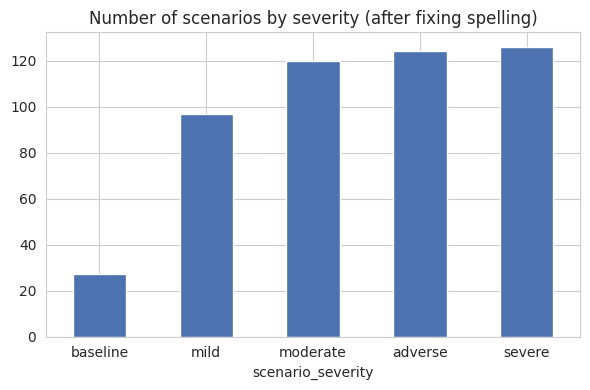

scenario_severity
baseline     27
mild         97
moderate    120
adverse     124
severe      126
Name: count, dtype: int64


In [7]:
SEVERITY_MAP = {
    'baseline': 'baseline',
    'mild': 'mild', 'mld': 'mild',
    'moderate': 'moderate', 'moderat': 'moderate',
    'adverse': 'adverse', 'advers': 'adverse',
    'severe': 'severe', 'sever': 'severe',
}

severity_preview = raw['scenario_severity'].str.strip().str.lower().map(SEVERITY_MAP)
order = ['baseline', 'mild', 'moderate', 'adverse', 'severe']
counts = severity_preview.value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Number of scenarios by severity (after fixing spelling)')
ax.set_xlabel('scenario_severity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(counts)

**Conclusion.** Scenarios are fairly evenly spread across the five severity levels,
with no single level dominating. A small number of rows (the blank or unreadable
labels) do not map to any of the five and are left out of this count, since guessing
their severity would not be honest.

## 6. Shock variable distributions and correlations

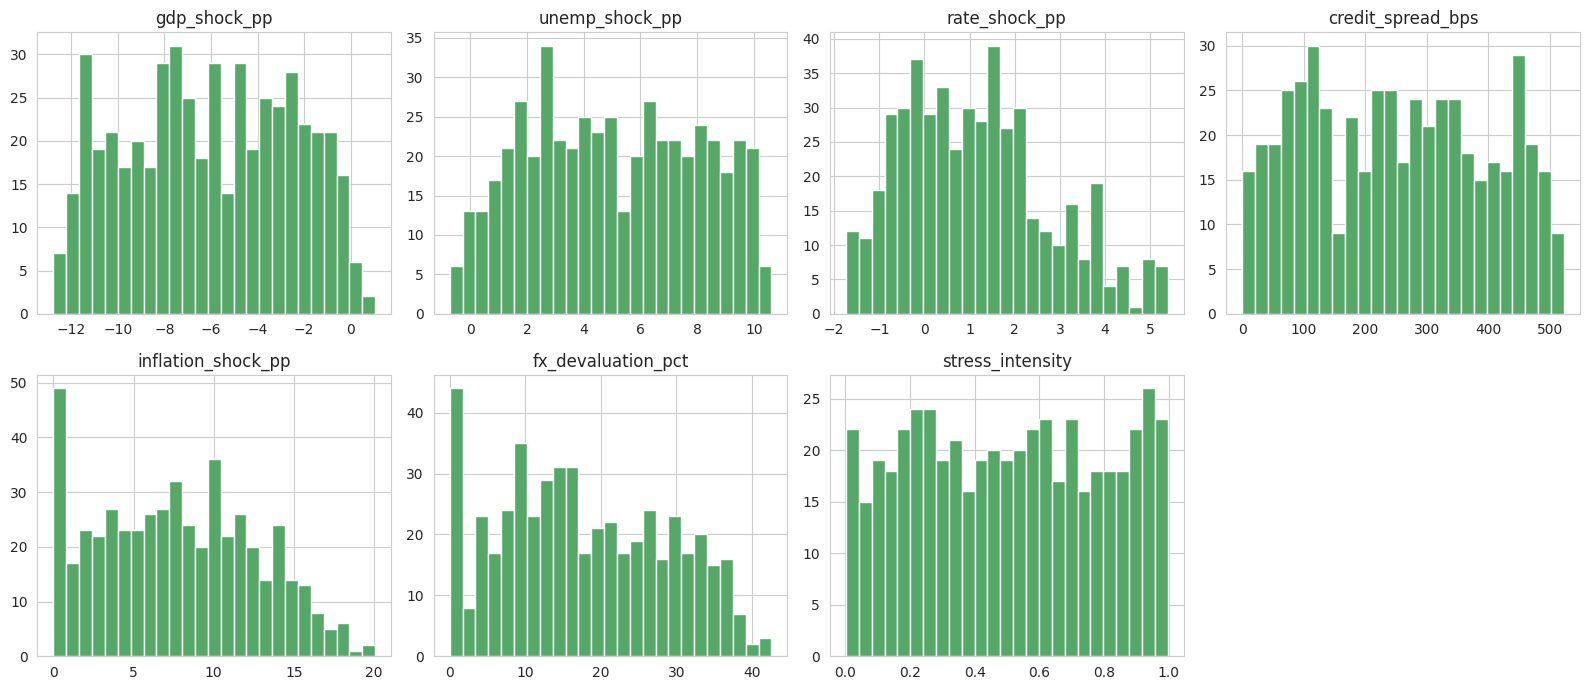

In [8]:
shock_cols = ['gdp_shock_pp', 'unemp_shock_pp', 'rate_shock_pp', 'credit_spread_bps',
              'inflation_shock_pp', 'fx_devaluation_pct', 'stress_intensity']

credit_spread_preview = pd.to_numeric(
    raw['credit_spread_bps'].str.lower().str.replace('bps', '', regex=False).str.strip(),
    errors='coerce')
rate_shock_preview = pd.to_numeric(raw['rate_shock_pp'], errors='coerce')

numeric_preview = raw[['gdp_shock_pp', 'unemp_shock_pp', 'inflation_shock_pp',
                        'fx_devaluation_pct', 'stress_intensity']].apply(pd.to_numeric, errors='coerce')
numeric_preview['credit_spread_bps'] = credit_spread_preview
numeric_preview['rate_shock_pp'] = rate_shock_preview
numeric_preview = numeric_preview[shock_cols]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for ax, col in zip(axes, shock_cols):
    numeric_preview[col].dropna().hist(ax=ax, bins=25, color='#55A868')
    ax.set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

**Conclusion.** `gdp_shock_pp` is mostly negative, which fits since it represents a
hit to growth. `rate_shock_pp` and `inflation_shock_pp` are centred closer to zero with
a wider spread in both directions. None of the shock variables show impossible values,
such as a negative `credit_spread_bps` or a currency devaluation in the thousands of
percent.

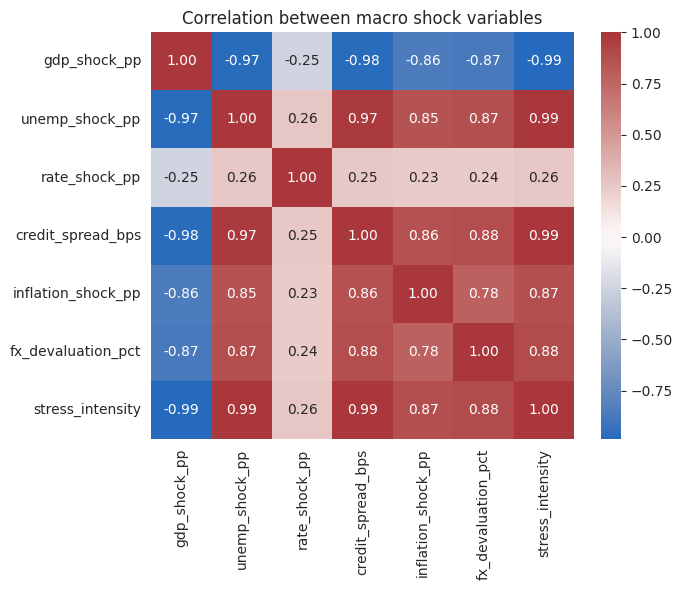

In [9]:
corr = numeric_preview.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax)
ax.set_title('Correlation between macro shock variables')
plt.tight_layout()
plt.show()

**Conclusion.** `stress_intensity` correlates fairly strongly with most of the shock
columns, which fits with it being a summary measure of how hard a scenario hits the
economy overall. `gdp_shock_pp` and `unemp_shock_pp` move in opposite directions, which
also matches how a recession normally behaves: growth falls while unemployment rises.

## 7. Do the shocks actually scale with severity?

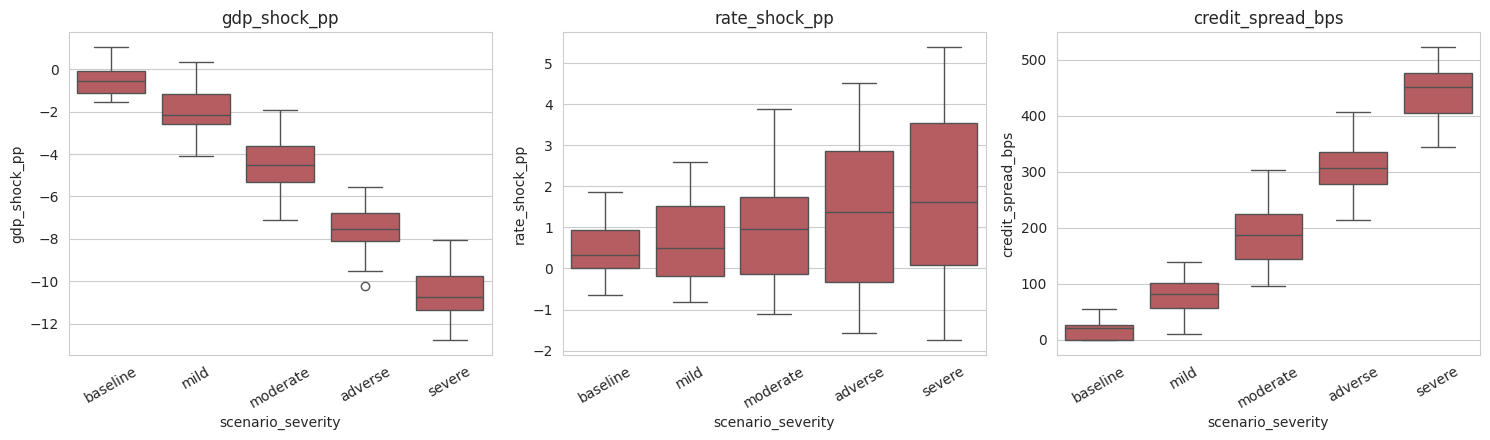

In [10]:
plot_df = pd.DataFrame({
    'scenario_severity': severity_preview,
    'gdp_shock_pp': numeric_preview['gdp_shock_pp'],
    'rate_shock_pp': numeric_preview['rate_shock_pp'],
    'credit_spread_bps': numeric_preview['credit_spread_bps'],
}).dropna(subset=['scenario_severity'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ['gdp_shock_pp', 'rate_shock_pp', 'credit_spread_bps']):
    sns.boxplot(data=plot_df, x='scenario_severity', y=col, order=order, ax=ax, color='#C44E52')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Conclusion.** The severity labels behave the way they should. `credit_spread_bps`
and `rate_shock_pp` both step up moving from baseline to severe, and `gdp_shock_pp`
gets more negative in the same direction. This means the severity label was assigned
consistently before the formatting problems were introduced, so fixing the spelling
back to five clean categories is the right move rather than treating severity as
unreliable.

## Summary of issues found

- 4 exact duplicate rows.
- `scenario_severity` has 15 variants of 5 real categories, plus a few unreadable
  entries (`unknown`, `TBD`).
- `credit_spread_bps` carries a trailing `bps` label on some rows.
- `rate_shock_pp` has a small number of missing values written as text tokens.

All of these are handled in `notebooks/data_cleaning.ipynb`, which writes the cleaned
result to `processed/macro_scenarios_clean.csv`.